# Exploratory Analysis of Temperature Data

This notebook performs initial exploratory data analysis on temperature data before Bayesian modeling.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append('../src')

from utils.data_loader import load_temperature_data, aggregate_to_annual, detect_outliers

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
# Load temperature data
# Replace with your actual data file path
time, temperature, df = load_temperature_data(
    filepath='../data/temperature_data.csv',
    date_column='date',
    temp_column='temperature'
)

print(f"Data points: {len(temperature)}")
print(f"Time range: {time.min():.1f} - {time.max():.1f}")
print(f"Temperature range: {temperature.min():.2f}°C - {temperature.max():.2f}°C")

df.head()

Data points: 66
Time range: 1960.0 - 2025.0
Temperature range: 3.00°C - 6.40°C


,date,temperature,year,decimal_year
0,1960-01-15,3.0,1960,1960.03833
1,1961-01-15,3.2,1961,1961.03833
2,1962-01-15,3.1,1962,1962.03833
3,1963-01-15,3.3,1963,1963.03833
4,1964-01-15,3.2,1964,1964.03833


## 2. Visualize Time Series

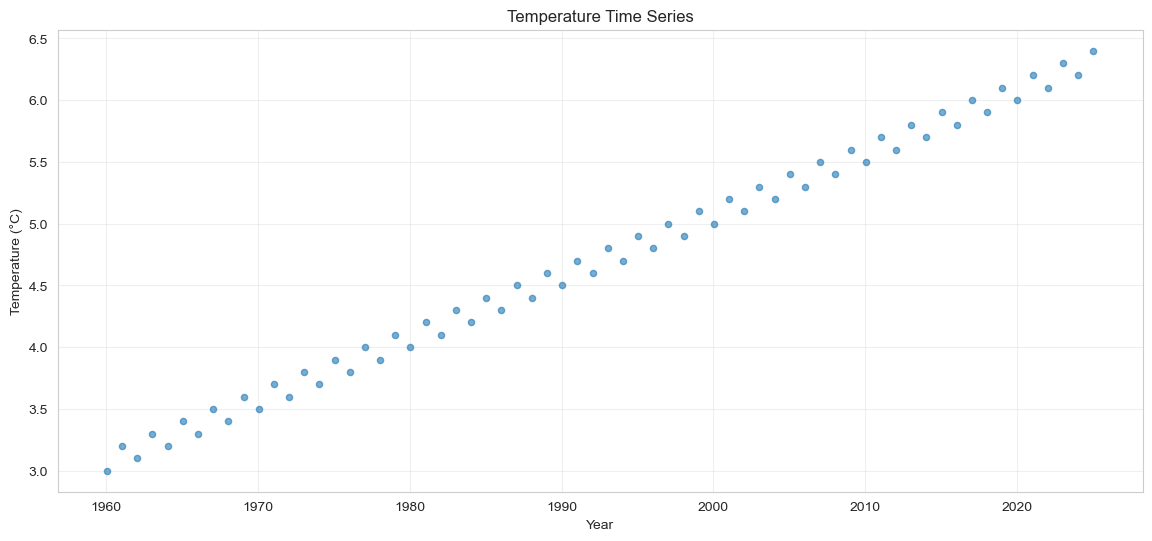

In [3]:
plt.figure(figsize=(14, 6))
plt.scatter(time, temperature, alpha=0.6, s=20)
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Time Series')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Statistical Summary

In [4]:
print("Temperature Statistics:")
print(f"  Mean:   {np.mean(temperature):.2f}°C")
print(f"  Median: {np.median(temperature):.2f}°C")
print(f"  Std:    {np.std(temperature):.2f}°C")
print(f"  Min:    {np.min(temperature):.2f}°C")
print(f"  Max:    {np.max(temperature):.2f}°C")

Temperature Statistics:
  Mean:   4.70°C
  Median: 4.70°C
  Std:    0.96°C
  Min:    3.00°C
  Max:    6.40°C


## 4. Distribution Analysis

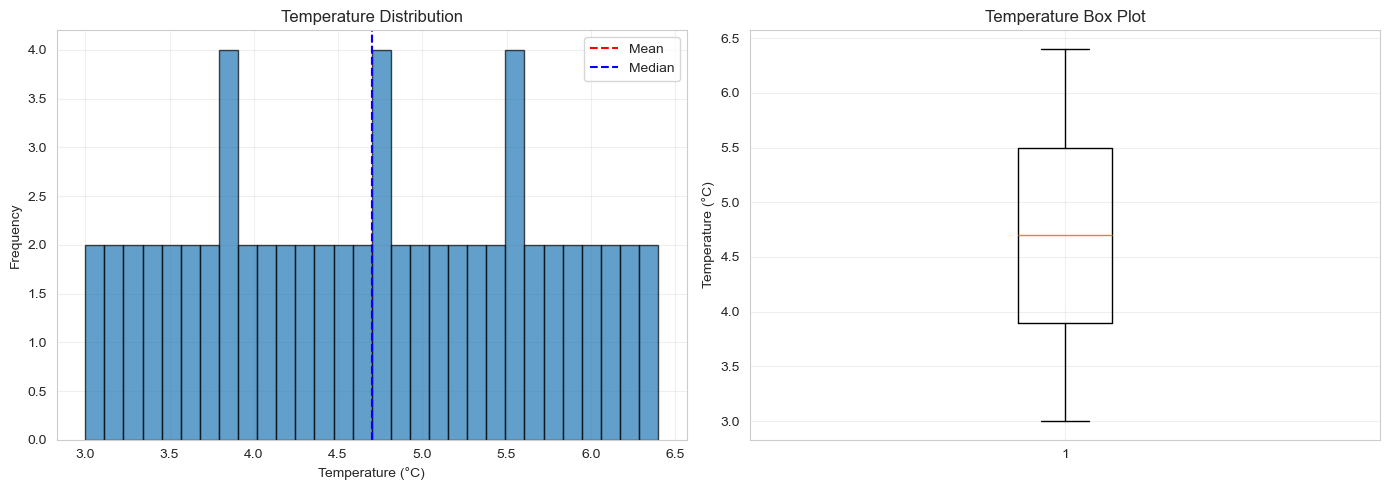

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(temperature, bins=30, alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(temperature), color='red', linestyle='--', label='Mean')
axes[0].axvline(np.median(temperature), color='blue', linestyle='--', label='Median')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Temperature Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(temperature, vert=True)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Temperature Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Detect Outliers

In [6]:
outliers = detect_outliers(temperature, n_sigma=3.0)
n_outliers = np.sum(outliers)

print(f"Number of outliers (3-sigma): {n_outliers}")

if n_outliers > 0:
    plt.figure(figsize=(14, 6))
    plt.scatter(time[~outliers], temperature[~outliers], alpha=0.6, s=20, label='Normal')
    plt.scatter(time[outliers], temperature[outliers], color='red', s=50, 
                marker='x', label=f'Outliers (n={n_outliers})')
    plt.xlabel('Year')
    plt.ylabel('Temperature (°C)')
    plt.title('Temperature Data with Outliers Highlighted')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Number of outliers (3-sigma): 0


## 6. Simple Linear Trend

Linear Regression Results:
  Slope:     0.0501 °C/year
  Intercept: -95.13 °C
  R²:        0.9939
  p-value:   1.5923e-72
  Std error: 0.0005


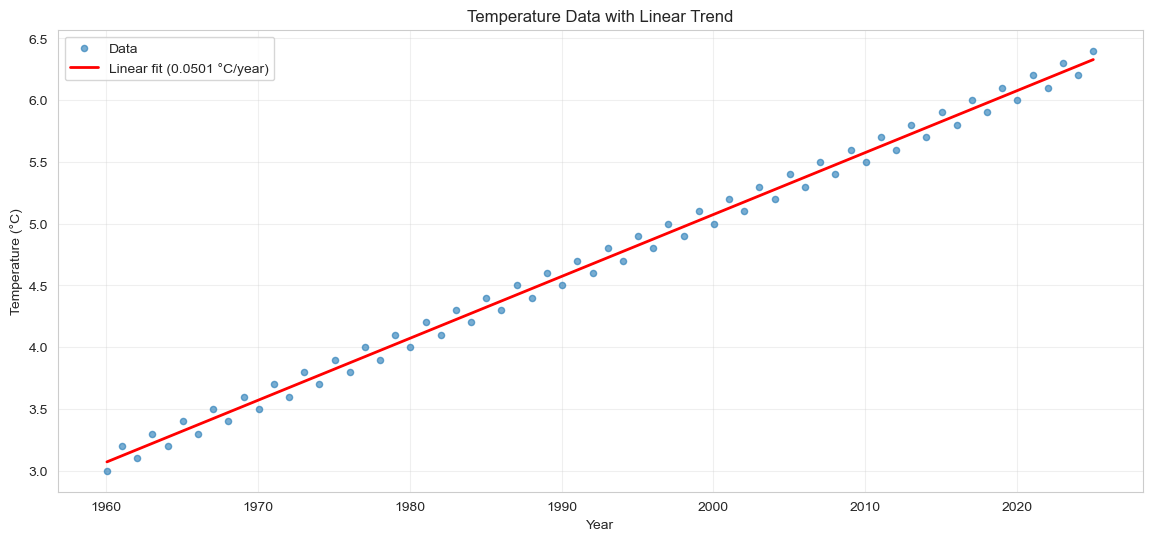

In [7]:
# Fit simple linear regression
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(time, temperature)

print(f"Linear Regression Results:")
print(f"  Slope:     {slope:.4f} °C/year")
print(f"  Intercept: {intercept:.2f} °C")
print(f"  R²:        {r_value**2:.4f}")
print(f"  p-value:   {p_value:.4e}")
print(f"  Std error: {std_err:.4f}")

# Plot
plt.figure(figsize=(14, 6))
plt.scatter(time, temperature, alpha=0.6, s=20, label='Data')
plt.plot(time, slope * time + intercept, 'r-', linewidth=2, 
         label=f'Linear fit ({slope:.4f} °C/year)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Data with Linear Trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Next Steps

1. Proceed to Bayesian analysis notebook for full uncertainty quantification
2. Consider seasonal patterns if high-frequency data
3. Explore hierarchical models for spatial data